In [32]:
# CIFAR : 캐나다 고등 연구소 약자
# 10 : 분류 10개
# - 비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배 , 트럭
# 이미지 총 6만장. 학습 5만, 테스트 1만
# 크기 32 x 32

In [33]:
# 데이터 생성, 독립/종속 분리, 훈련/테스트 분리

import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [34]:
# 10가지 분류명(확인용)
class_names = [
  'airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'
]


In [35]:
# 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

In [36]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
# 콜백

callbacks = [
	# 조기 종료
  EarlyStopping(monitor = 'val_loss', patience = 5, restore_best_weights =True),
	# 최고 성능 모델
  ModelCheckpoint(filepath='best_cifar10_model.keras', monitor = 'val_accuracy',
                  save_best_only = True, verbose=1),
	# 학습률 동적 조절
	ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience = 3, min_lr=1e-6)

]

In [37]:
# 파이프라인
from tensorflow.data import Dataset

DATASET_SIZE = 50000
TRAIN_SIZE = int(DATASET_SIZE * 0.8)
VAL_SIZE = int(DATASET_SIZE * 0.2) # 검증 사이즈 
dataset = Dataset.from_tensor_slices((X_train, y_train))

# 섞음
dataset = dataset.shuffle(buffer_size = DATASET_SIZE)
# 훈련 데이터 셋
train_dataset = dataset.take(TRAIN_SIZE)
# 검증 데이터 셋
val_dataset = dataset.skip(TRAIN_SIZE)

train_dataset = train_dataset.batch(128).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(128).prefetch(tf.data.AUTOTUNE)

In [38]:
# 데이터 증강 : 이미지를 돌리거나, 색상 반전등과 같이 변형을 한 복사본을 만들어 학습

data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"), # 좌 우 반전
  tf.keras.layers.RandomRotation(0.2) # 20% 범위 내에서 무작위 회전
])

In [39]:
# 모델 설계

model = tf.keras.models.Sequential([
  tf.keras.Input((32, 32, 3)), # 크기, 크기, 채널(RGB라 3개, 흑백은 1개)
  
	# 데이터 증강
  # data_augmentation,

  # 정규화 
  tf.keras.layers.Rescaling(1./255),
	
	# 블록 1
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'), #(N(32)개의 특징을 분석하겠다)
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),
  # 이 때 이미지 크기 16 x 16(풀링시 반씩 줄어들기 때문에)

	# 블록 2
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
	tf.keras.layers.MaxPooling2D(2,2),
	tf.keras.layers.Dropout(0.25),
  #  이 때 이미지 크기 8 x 8

	# 블록 3
	tf.keras.layers.Conv2D(128, (3,3), padding='same', activation='relu'),
	tf.keras.layers.BatchNormalization(),
	tf.keras.layers.GlobalAveragePooling2D(), # 파라미터 줄이고 안정화 

	# 분류기
	tf.keras.layers.Dense(10, activation='softmax'),
  
])

In [40]:
# 모델 설정
model.compile(
  optimizer = 'adam',
  loss = 'sparse_categorical_crossentropy',
  metrics=['accuracy']
)

In [41]:
# 학습
history = model.fit(
  train_dataset,
  epochs = 50,
  verbose = 1,
  validation_data = val_dataset,
  callbacks = callbacks,
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.3756 - loss: 1.6975
Epoch 1: val_accuracy improved from None to 0.11350, saving model to best_cifar10_model.keras

Epoch 1: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 283ms/step - accuracy: 0.4599 - loss: 1.4935 - val_accuracy: 0.1135 - val_loss: 3.2596 - learning_rate: 0.0010
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.5867 - loss: 1.1713
Epoch 2: val_accuracy improved from 0.11350 to 0.14210, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 255ms/step - accuracy: 0.6038 - loss: 1.1235 - val_accuracy: 0.1421 - val_loss: 2.8456 - learning_rate: 0.0010
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.6503 - loss: 0.9963
Epoch 3: val_accuracy improved from 0.14210 to 0.63330, saving model to best_cifar10_model.keras

Epoch 3: finished saving model to best_

In [42]:
# 평가
_, acc = model.evaluate(X_test, y_test)
print(f'정확도 : {acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8209 - loss: 0.5344
정확도 : 0.820900022983551


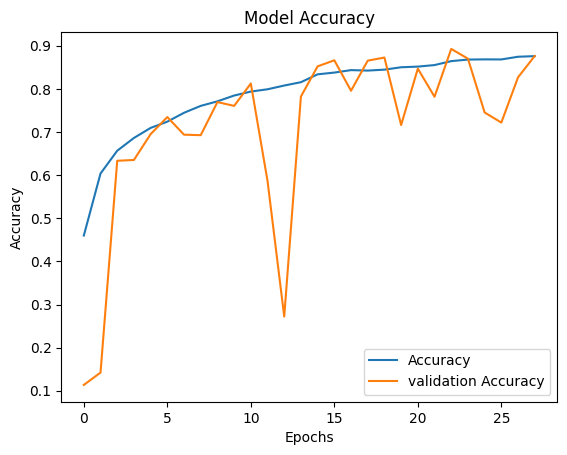

In [43]:
# 성능 시각화 
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


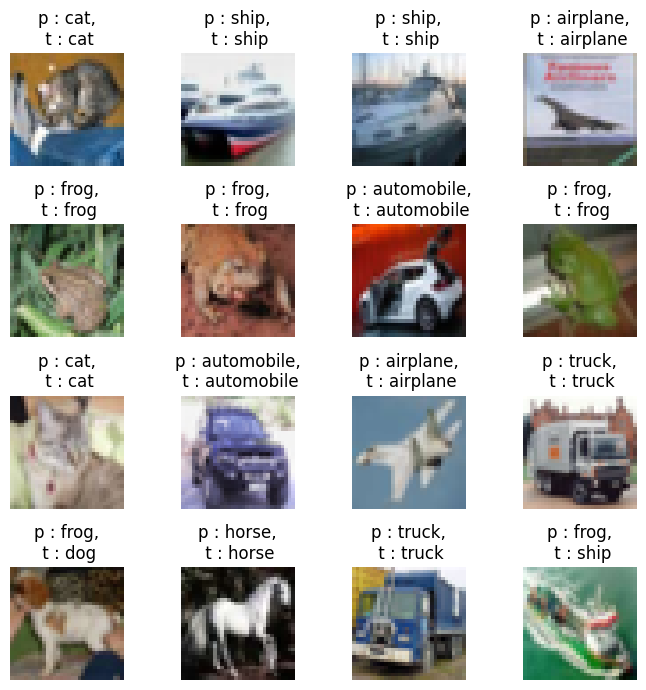

In [44]:
# 이미지 시각화 

predictions = model.predict(X_test[:16])

fig, axes = plt.subplots(4, 4, figsize=(7,7))
for i, ax in enumerate(axes.flat):
  ax.imshow(X_test[i])
  predict = predictions[i].argmax()
  true = y_test[i][0]
  ax.set_title(f"p : {class_names[predict]},\n t : {class_names[true]}")
  ax.axis('off')
plt.tight_layout()
plt.show()

In [45]:
import cv2 
import numpy as np

# 예측
def model_predict_idx(model, img_path):
  
	img = cv2.imread(img_path, cv2.IMREAD_COLOR)

	resize_img = cv2.resize(img, (32, 32))
	predict = model.predict(np.array([resize_img]))

	result = np.argmax(predict)
	return  class_names[result]

In [46]:
result = model_predict_idx(model, '../data/img/cifar10_5_1.png')
print(f'dog? {result}')
result = model_predict_idx(model, '../data/img/cifar10_5_2.png')
print(f'dog? {result}')
result = model_predict_idx(model, '../data/img/cifar10_3_1.png')
print(f'cat? {result}')
result = model_predict_idx(model, '../data/img/cifar10_0_1.png')
print(f'Airplane? {result}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
dog? bird
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
dog? dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
cat? cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Airplane? automobile
